In [1]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
)

from joblib import dump
import matplotlib.pyplot as plt

In [2]:
# Project paths – adjust PROJECT_DIR if your folder is elsewhere
PROJECT_DIR = Path("/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av")
DATA_DIR    = PROJECT_DIR / "data" / "cape"

# Your CAPE files
LABELS_PATH = DATA_DIR / "public_labels.csv"      # uploaded labels file
REPORTS_DIR = DATA_DIR / "public_small_reports"   # folder of JSON reports

# Where to save models/vectorisers
MODEL_DIR   = PROJECT_DIR / "saved" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Labels path:", LABELS_PATH)
print("Reports dir:", REPORTS_DIR)
print("Model dir:", MODEL_DIR)

Labels path: /Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/data/cape/public_labels.csv
Reports dir: /Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/data/cape/public_small_reports
Model dir: /Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/saved/models


In [3]:
# --- DEBUG CELL: inspect labels and a few JSONs ---

labels_df = pd.read_csv(LABELS_PATH)
print("Labels CSV shape:", labels_df.shape)
print("Columns:", labels_df.columns.tolist())
print(labels_df.head())

# check presence of JSON files for first 5 rows
print("\nChecking JSON existence for first 5 rows:")
for i, row in labels_df.head(5).iterrows():
    sha = row["sha256"]
    fam = row["classification_family"]
    json_path = REPORTS_DIR / f"{sha}.json"
    print(f"{i}: sha={sha}, family={fam}, exists={json_path.exists()}, path='{json_path}'")

Labels CSV shape: (48976, 4)
Columns: ['sha256', 'classification_family', 'classification_type', 'date']
                                              sha256 classification_family  \
0  00003d128a7eb859f65f5780d8fa2b5e52d472665678bf...                Qakbot   
1  0000698621e473a0828c1c957873e7d086f2d90eebc6a3...                Swisyn   
2  0000a65749f5902c4d82ffa701198038f0b4870b00a27c...                Qakbot   
3  0001770a2a6e888a123775fc24d8a4ffccc5c8191c1c2a...                Emotet   
4  000376a4b234f57ae0f1fb959817486040d7d8d8be1fbc...                Emotet   

  classification_type        date  
0              banker  2019-03-20  
1              trojan  2019-11-16  
2              banker  2018-06-25  
3              banker  2019-10-06  
4              banker  2019-09-30  

Checking JSON existence for first 5 rows:
0: sha=00003d128a7eb859f65f5780d8fa2b5e52d472665678bf6e388e857fbaed773a, family=Qakbot, exists=True, path='/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybri

In [4]:
# find first label whose JSON actually exists
existing = None
for i, row in labels_df.iterrows():
    sha = row["sha256"]
    json_path = REPORTS_DIR / f"{sha}.json"
    if json_path.exists():
        existing = (i, sha, json_path)
        break

if existing is None:
    print("No JSON files found that match any sha256 from labels.csv.")
else:
    i, sha, json_path = existing
    print(f"\nFirst existing JSON: row {i}, sha={sha}, path={json_path}")
    with open(json_path, "r") as f:
        report = json.load(f)

    print("Top-level keys:", list(report.keys()))

    # peek into likely places for API calls
    behavior = report.get("behavior", {})
    print("behavior keys:", list(behavior.keys()))

    if "processes" in behavior:
        print("Number of processes:", len(behavior["processes"]))
        if behavior["processes"]:
            first_proc = behavior["processes"][0]
            print("First process keys:", list(first_proc.keys()))
            if "calls" in first_proc:
                print("Number of calls in first process:", len(first_proc["calls"]))
                if first_proc["calls"]:
                    print("First call example:", first_proc["calls"][0])
    if "apistats" in behavior:
        print("apistats keys (truncated):", list(behavior["apistats"].keys())[:10])

    summary = report.get("summary", {})
    print("summary keys:", list(summary.keys()))


First existing JSON: row 0, sha=00003d128a7eb859f65f5780d8fa2b5e52d472665678bf6e388e857fbaed773a, path=/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/data/cape/public_small_reports/00003d128a7eb859f65f5780d8fa2b5e52d472665678bf6e388e857fbaed773a.json
Top-level keys: ['behavior', 'static']
behavior keys: ['summary']
summary keys: []


In [5]:
MIN_API_LEN = 10  # start with 10 for the small reports; we can increase later if needed

def normalise_api_name(name: str) -> str:
    """
    Normalise an API / function / signature name by:
    - dropping anything after '('
    - stripping whitespace
    - lowercasing
    """
    if not isinstance(name, str):
        return ""
    base = name.split("(")[0]
    return base.strip().lower()


def extract_api_sequence(report_json: dict) -> list[str]:
    """
    Extract a flat list of 'API-like' tokens from a CAPE report.

    It tries several common layouts:
      1) behavior.processes[*].calls[*].api            (full dynamic traces)
      2) behavior.apistats                             (aggregated API counts)
      3) behavior.summary[...]                         (CAPE summary section)
      4) static.pe_imports / static.imports            (DLL import names)  [fallback]
    """
    seq: list[str] = []

    behavior = report_json.get("behavior", {})

    # --- 1) behavior.processes[*].calls[*].api ---
    processes = behavior.get("processes", []) or []
    for proc in processes:
        for call in proc.get("calls", []) or []:
            api = call.get("api") or call.get("call")
            if api:
                seq.append(normalise_api_name(api))

    # --- 2) behavior.apistats: {proc_name: {api_name: count}} ---
    apistats = behavior.get("apistats", {})
    if isinstance(apistats, dict):
        for proc_name, api_dict in apistats.items():
            if isinstance(api_dict, dict):
                for api_name, count in api_dict.items():
                    try:
                        c = int(count)
                    except Exception:
                        c = 1
                    c = max(c, 1)
                    for _ in range(c):
                        seq.append(normalise_api_name(api_name))

    # --- 3) behavior.summary ---
    # In your debug, 'behavior keys: ["summary"]', so we *must* look here.
    beh_summary = behavior.get("summary", {})

    # The format can vary: dict of lists, dict of dicts, or even a list.
    def add_from_summary(obj):
        # inner helper to walk arbitrary nested structures
        if isinstance(obj, dict):
            for k, v in obj.items():
                # keys sometimes are API names themselves
                if isinstance(k, str):
                    seq.append(normalise_api_name(k))
                add_from_summary(v)
        elif isinstance(obj, list):
            for item in obj:
                add_from_summary(item)
        elif isinstance(obj, str):
            # treat strings as API-like tokens / signatures
            seq.append(normalise_api_name(obj))
        # other types are ignored

    add_from_summary(beh_summary)

    # --- 4) static imports (optional fallback) ---
    static = report_json.get("static", {})

    # CAPE PE imports often live in "pe_imports".
    # They look like: [{"dll": "KERNEL32.dll", "imports": [{"name": "CreateFileW"}, ...]}, ...]
    pe_imports = static.get("pe_imports") or static.get("imports")
    if isinstance(pe_imports, list):
        for entry in pe_imports:
            if not isinstance(entry, dict):
                continue
            imports = entry.get("imports", [])
            for imp in imports:
                if isinstance(imp, dict):
                    name = imp.get("name") or imp.get("symbol") or imp.get("function")
                    if name:
                        seq.append(normalise_api_name(name))

    # remove empty strings just in case
    seq = [s for s in seq if s]

    return seq


def build_cape_df(
    labels_path: Path,
    reports_dir: Path,
    min_api_len: int = MIN_API_LEN,
    max_samples: int | None = None,
    hash_col: str = "sha256",
    family_col: str = "classification_family",
) -> pd.DataFrame:
    """
    Build a DataFrame with columns:
      sha256, family, api_seq (list[str]), api_text_full (joined string), num_calls

    Implements:
    - selection & filters from methodology
    - deduplication by sha256
    - skipping JSONs with errors / missing behavior
    """
    labels_df = pd.read_csv(labels_path)

    if hash_col not in labels_df.columns:
        raise ValueError(
            f"Hash column '{hash_col}' not found in labels CSV. "
            f"Available columns: {labels_df.columns.tolist()}"
        )
    if family_col not in labels_df.columns:
        raise ValueError(
            f"Family column '{family_col}' not found in labels CSV. "
            f"Available columns: {labels_df.columns.tolist()}"
        )

    rows = []
    seen_hashes: set[str] = set()

    for _, row in labels_df.iterrows():
        sha256 = row[hash_col]
        family = row[family_col]

        # basic label sanity (skip missing families)
        if pd.isna(family) or str(family).strip() in ("", "unknown", "UNK", "nan"):
            continue

        if sha256 in seen_hashes:
            continue  # dedupe

        json_path = reports_dir / f"{sha256}.json"
        if not json_path.exists():
            continue

        try:
            with open(json_path, "r") as f:
                report = json.load(f)
        except json.JSONDecodeError:
            # skip broken JSONs (errors or missing data)
            continue

        api_seq = extract_api_sequence(report)

        # If there are no tokens at all, skip
        if not api_seq:
            continue

        if len(api_seq) < min_api_len:
            # remove very short traces
            continue

        seen_hashes.add(str(sha256))
        rows.append({
            "sha256": str(sha256),
            "family": str(family),
            "api_seq": api_seq,
        })

        if max_samples is not None and len(rows) >= max_samples:
            break

    cape_df = pd.DataFrame(rows)
    if cape_df.empty:
        print("WARNING: build_cape_df produced 0 samples.")
        print("  -> Try lowering MIN_API_LEN or inspect extract_api_sequence().")
        return cape_df

    cape_df["num_calls"] = cape_df["api_seq"].str.len()
    cape_df["api_text_full"] = cape_df["api_seq"].apply(lambda seq: " ".join(seq))

    return cape_df

In [6]:
cape_df = build_cape_df(
    LABELS_PATH,
    REPORTS_DIR,
    min_api_len=MIN_API_LEN,  # 10
)

print("CAPE dataset after filtering:")
print("  #samples:", len(cape_df))
print("  #families:", cape_df["family"].nunique())
print("\nTop 10 families:")
print(cape_df["family"].value_counts().head(10))

CAPE dataset after filtering:
  #samples: 48976
  #families: 10

Top 10 families:
family
Emotet      14429
Swisyn      12591
Qakbot       4895
Trickbot     4202
Lokibot      4191
njRAT        3372
Zeus         2594
Ursnif       1343
Adload        704
HarHar        655
Name: count, dtype: int64


In [7]:
# Deterministic shuffle
cape_df = cape_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

X_text = cape_df["api_text_full"]
y      = cape_df["family"]

# 60% train, 20% val, 20% test (stratified by family)
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42,
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42,
)

print("Train/val/test sizes:", len(X_train_text), len(X_val_text), len(X_test_text))
print("Num families in train:", y_train.nunique())

Train/val/test sizes: 29385 9795 9796
Num families in train: 10


In [8]:
vectorizer_params = {
    "ngram_range": (1, 2),   # unigrams + bigrams
    "max_features": 5000,    # vocabulary cap
    "min_df": 5,             # drop very rare APIs
}

vectorizer = TfidfVectorizer(**vectorizer_params)

X_train = vectorizer.fit_transform(X_train_text)
X_val   = vectorizer.transform(X_val_text)
X_test  = vectorizer.transform(X_test_text)

X_train.shape, X_val.shape, X_test.shape

((29385, 5000), (9795, 5000), (9796, 5000))

In [9]:
rf_grid = [
    {"n_estimators": 200, "max_depth": 30},
    {"n_estimators": 500, "max_depth": 30},
    {"n_estimators": 500, "max_depth": None},
]

behavior_rf_results = []

for cfg in rf_grid:
    print("Training RF config:", cfg)
    rf = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_train, y_train)

    y_val_pred = rf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1m = f1_score(y_val, y_val_pred, average="macro")

    behavior_rf_results.append({
        "model": "Behavior_RF",
        "n_estimators": cfg["n_estimators"],
        "max_depth": cfg["max_depth"],
        "val_accuracy": acc,
        "val_macro_f1": f1m,
    })

behavior_rf_search_df = pd.DataFrame(behavior_rf_results)
behavior_rf_search_df

Training RF config: {'n_estimators': 200, 'max_depth': 30}
Training RF config: {'n_estimators': 500, 'max_depth': 30}
Training RF config: {'n_estimators': 500, 'max_depth': None}


,model,n_estimators,max_depth,val_accuracy,val_macro_f1
0,Behavior_RF,200,30.0,0.990914,0.987825
1,Behavior_RF,500,30.0,0.990914,0.987454
2,Behavior_RF,500,NaN,0.990914,0.987610


In [10]:
best_idx = behavior_rf_search_df["val_macro_f1"].idxmax()
best_rf_cfg = behavior_rf_search_df.loc[best_idx]

best_rf_cfg

model           Behavior_RF
n_estimators            200
max_depth              30.0
val_accuracy       0.990914
val_macro_f1       0.987825
Name: 0, dtype: object

In [11]:
# Combine train + val texts/labels
X_train_full_text = pd.concat([X_train_text, X_val_text], axis=0)
y_train_full      = pd.concat([y_train, y_val], axis=0)

# New vectorizer fitted on train+val only
vectorizer_behavior = TfidfVectorizer(**vectorizer_params)
X_train_full = vectorizer_behavior.fit_transform(X_train_full_text)
X_test_full  = vectorizer_behavior.transform(X_test_text)

best_behavior_rf = RandomForestClassifier(
    n_estimators=int(best_rf_cfg["n_estimators"]),
    max_depth=(None if pd.isna(best_rf_cfg["max_depth"]) else int(best_rf_cfg["max_depth"])),
    n_jobs=-1,
    random_state=42,
)
best_behavior_rf.fit(X_train_full, y_train_full)

y_test_pred_beh = best_behavior_rf.predict(X_test_full)

test_acc_beh = accuracy_score(y_test, y_test_pred_beh)
test_macro_f1_beh = f1_score(y_test, y_test_pred_beh, average="macro")

print("Behavior-only RF (best config) – test set:")
print(f"  Accuracy:  {test_acc_beh:.4f}")
print(f"  Macro-F1:  {test_macro_f1_beh:.4f}")
print()
print("Classification report:")
print(classification_report(y_test, y_test_pred_beh))

Behavior-only RF (best config) – test set:
  Accuracy:  0.9895
  Macro-F1:  0.9848

Classification report:
              precision    recall  f1-score   support

      Adload       1.00      1.00      1.00       141
      Emotet       0.99      1.00      0.99      2886
      HarHar       1.00      1.00      1.00       131
     Lokibot       0.99      0.97      0.98       838
      Qakbot       1.00      0.99      1.00       979
      Swisyn       1.00      1.00      1.00      2518
    Trickbot       0.99      1.00      0.99       841
      Ursnif       0.98      0.97      0.97       268
        Zeus       0.96      0.95      0.95       519
       njRAT       0.96      0.96      0.96       675

    accuracy                           0.99      9796
   macro avg       0.99      0.98      0.98      9796
weighted avg       0.99      0.99      0.99      9796



In [12]:
dump(best_behavior_rf, MODEL_DIR / "cape_behavior_rf_best.pkl")
dump(vectorizer_behavior, MODEL_DIR / "cape_behavior_tfidf.pkl")

['/Users/anmoulmalhotra/Documents/ProjectDissertationDir/hybrid-av/saved/models/cape_behavior_tfidf.pkl']

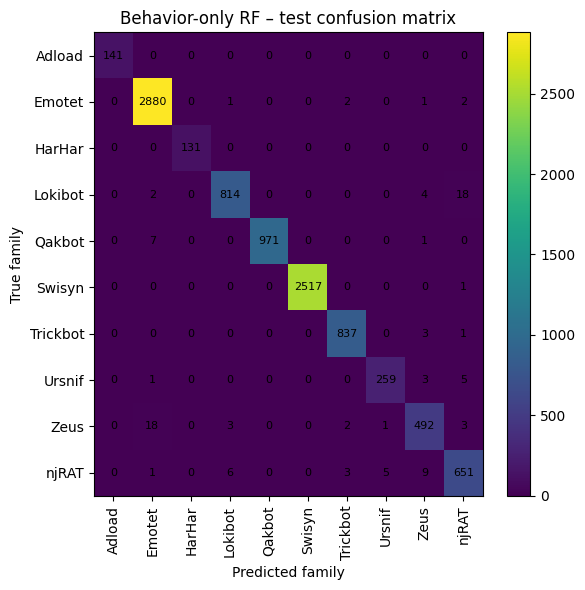

In [13]:
cm_beh = confusion_matrix(y_test, y_test_pred_beh, labels=sorted(y_test.unique()))

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm_beh, aspect="auto")

ax.set_xticks(range(len(cm_beh)))
ax.set_yticks(range(len(cm_beh)))
ax.set_xticklabels(sorted(y_test.unique()), rotation=90)
ax.set_yticklabels(sorted(y_test.unique()))

ax.set_xlabel("Predicted family")
ax.set_ylabel("True family")
ax.set_title("Behavior-only RF – test confusion matrix")

for i in range(cm_beh.shape[0]):
    for j in range(cm_beh.shape[1]):
        ax.text(j, i, cm_beh[i, j],
                ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [14]:
# Count families and pick top-K by frequency
family_counts = Counter(cape_df["family"])
TOP_K = 10  # adjust as needed

top_k_families = [fam for fam, _ in family_counts.most_common(TOP_K)]
top_k_families

['Emotet',
 'Swisyn',
 'Qakbot',
 'Trickbot',
 'Lokibot',
 'njRAT',
 'Zeus',
 'Ursnif',
 'Adload',
 'HarHar']

In [15]:
lofo_results = []

for held_out_family in top_k_families:
    print(f"\nLOFO – held-out family: {held_out_family}")

    train_df = cape_df[cape_df["family"] != held_out_family]
    test_df  = cape_df[cape_df["family"] == held_out_family]

    # Skip families with very few samples to keep estimates meaningful
    if len(test_df) < 20:
        print(f"  Skipping {held_out_family} (only {len(test_df)} samples).")
        continue

    # Vectorizer fit only on training families
    vec_lofo = TfidfVectorizer(**vectorizer_params)
    X_train_lofo = vec_lofo.fit_transform(train_df["api_text_full"])
    X_test_lofo  = vec_lofo.transform(test_df["api_text_full"])

    y_train_lofo = train_df["family"]
    y_test_lofo  = test_df["family"]

    rf_lofo = RandomForestClassifier(
        n_estimators=int(best_rf_cfg["n_estimators"]),
        max_depth=(None if pd.isna(best_rf_cfg["max_depth"]) else int(best_rf_cfg["max_depth"])),
        n_jobs=-1,
        random_state=42,
    )
    rf_lofo.fit(X_train_lofo, y_train_lofo)

    y_pred_lofo = rf_lofo.predict(X_test_lofo)

    # "detection rate on held-out family" = recall on that family
    detection_rate = np.mean(y_pred_lofo == held_out_family)

    # F1 for the held-out family as a single-class metric
    f1_held_out = f1_score(
        y_test_lofo,
        y_pred_lofo,
        labels=[held_out_family],
        average="macro",
    )

    lofo_results.append({
        "held_out_family": held_out_family,
        "n_test": len(test_df),
        "detection_rate": detection_rate,
        "f1_held_out": f1_held_out,
    })

lofo_df = pd.DataFrame(lofo_results)
lofo_df


LOFO – held-out family: Emotet

LOFO – held-out family: Swisyn

LOFO – held-out family: Qakbot

LOFO – held-out family: Trickbot

LOFO – held-out family: Lokibot

LOFO – held-out family: njRAT

LOFO – held-out family: Zeus

LOFO – held-out family: Ursnif

LOFO – held-out family: Adload

LOFO – held-out family: HarHar


,held_out_family,n_test,detection_rate,f1_held_out
0,Emotet,14429,0.0,0.0
1,Swisyn,12591,0.0,0.0
2,Qakbot,4895,0.0,0.0
3,Trickbot,4202,0.0,0.0
4,Lokibot,4191,0.0,0.0
5,njRAT,3372,0.0,0.0
6,Zeus,2594,0.0,0.0
7,Ursnif,1343,0.0,0.0
8,Adload,704,0.0,0.0
9,HarHar,655,0.0,0.0


In [16]:
# Map back from texts to api_seq using the index alignment in cape_df
#used cape_df["api_text_full"] when split so the indices match
train_idx = X_train_text.index
val_idx   = X_val_text.index
test_idx  = X_test_text.index

train_seqs = cape_df.loc[train_idx, "api_seq"]
val_seqs   = cape_df.loc[val_idx,   "api_seq"]
test_seqs  = cape_df.loc[test_idx,  "api_seq"]

train_labels = y_train
val_labels   = y_val
test_labels  = y_test

In [17]:
budgets = [50, 100, 200, None]  # None = full sequence (baseline)

robust_beh_results = []

for budget in budgets:
    label = "full" if budget is None else f"{budget}"

    def trunc(seq):
        if budget is None:
            return seq
        return seq[:budget]

    train_text_budget = train_seqs.apply(lambda s: " ".join(trunc(s)))
    val_text_budget   = val_seqs.apply(lambda s: " ".join(trunc(s)))
    test_text_budget  = test_seqs.apply(lambda s: " ".join(trunc(s)))

    vec = TfidfVectorizer(**vectorizer_params)
    X_train_b = vec.fit_transform(train_text_budget)
    X_val_b   = vec.transform(val_text_budget)
    X_test_b  = vec.transform(test_text_budget)

    rf_b = RandomForestClassifier(
        n_estimators=int(best_rf_cfg["n_estimators"]),
        max_depth=(None if pd.isna(best_rf_cfg["max_depth"]) else int(best_rf_cfg["max_depth"])),
        n_jobs=-1,
        random_state=42,
    )
    rf_b.fit(X_train_b, train_labels)

    y_val_pred_b  = rf_b.predict(X_val_b)
    y_test_pred_b = rf_b.predict(X_test_b)

    val_acc_b  = accuracy_score(val_labels,  y_val_pred_b)
    val_f1_b   = f1_score(val_labels,  y_val_pred_b,  average="macro")
    test_acc_b = accuracy_score(test_labels, y_test_pred_b)
    test_f1_b  = f1_score(test_labels, y_test_pred_b, average="macro")

    robust_beh_results.append({
        "budget_label": label,
        "budget_calls": (0 if budget is None else budget),
        "val_accuracy": val_acc_b,
        "val_macro_f1": val_f1_b,
        "test_accuracy": test_acc_b,
        "test_macro_f1": test_f1_b,
    })

robust_beh_df = pd.DataFrame(robust_beh_results)
robust_beh_df

,budget_label,budget_calls,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1
0,50,50,0.979479,0.969571,0.980604,0.969783
1,100,100,0.983461,0.976875,0.984177,0.977123
2,200,200,0.987545,0.982775,0.988056,0.982170
3,full,0,0.990914,0.987825,0.989281,0.984815


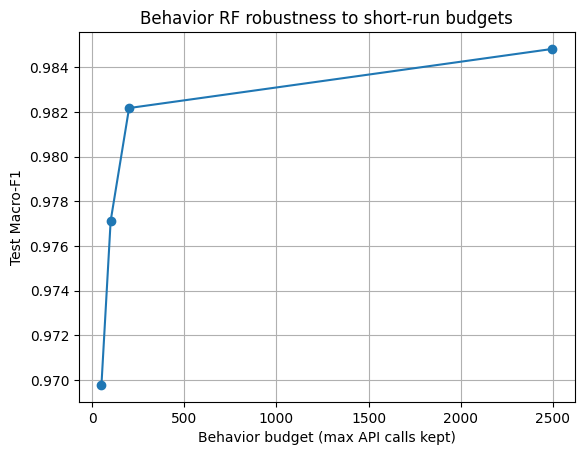

In [18]:
# for plotting purpose here we treat full sequence as the max observed length across train+val+test
max_len_full = int(cape_df["num_calls"].quantile(0.9))  # approximate full budget

df_plot = robust_beh_df.copy()
df_plot.loc[df_plot["budget_label"] == "full", "budget_calls"] = max_len_full

df_plot = df_plot.sort_values("budget_calls")

plt.figure()
plt.plot(df_plot["budget_calls"], df_plot["test_macro_f1"], marker="o")
plt.xlabel("Behavior budget (max API calls kept)")
plt.ylabel("Test Macro-F1")
plt.title("Behavior RF robustness to short-run budgets")
plt.grid(True)
plt.show()

In [19]:
# AURC over test Macro-F1 vs budget_calls
x = df_plot["budget_calls"].values.astype(float)
y = df_plot["test_macro_f1"].values.astype(float)

dx    = np.diff(x)
avg_y = (y[1:] + y[:-1]) / 2.0
aurc_beh = np.sum(avg_y * dx)

max_range = x.max() - x.min()
aurc_beh_norm = aurc_beh / max_range if max_range > 0 else np.nan

print("Behavior RF robustness to short runs:")
print("  AURC (unnormalised):", round(float(aurc_beh), 4))
print("  AURC (normalised 0-1):", round(float(aurc_beh_norm), 4))

Behavior RF robustness to short runs:
  AURC (unnormalised): 2406.7041
  AURC (normalised 0-1): 0.9831


In [20]:
import time
import os

def time_model_dense(model, X_train, y_train, X_test):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    _ = model.predict(X_test)
    predict_time = time.time() - start

    return train_time, predict_time

# Reuse X_train_full / X_test_full and best_behavior_rf config
rf_for_timing = RandomForestClassifier(
    n_estimators=int(best_rf_cfg["n_estimators"]),
    max_depth=(None if pd.isna(best_rf_cfg["max_depth"]) else int(best_rf_cfg["max_depth"])),
    n_jobs=-1,
    random_state=42,
)

train_t_beh, pred_t_beh = time_model_dense(
    rf_for_timing,
    X_train_full,
    y_train_full,
    X_test_full,
)

# Save and measure size
beh_model_path = MODEL_DIR / "cape_behavior_rf_best.pkl"
dump(rf_for_timing, beh_model_path)
beh_model_size_mb = os.path.getsize(beh_model_path) / 1024**2

cost_behavior = pd.DataFrame([{
    "model": "Behavior_RF",
    "train_time_s": train_t_beh,
    "predict_time_s": pred_t_beh,
    "predict_time_per_sample_ms": 1000 * pred_t_beh / X_test_full.shape[0],
    "model_size_MB": beh_model_size_mb,
}])

cost_behavior

,model,train_time_s,predict_time_s,predict_time_per_sample_ms,model_size_MB
0,Behavior_RF,10.925131,0.383823,0.039182,28.527413


In [21]:
import time

#we reuse the same budgets list we used for robustness
#budgets=[50, 100, 200, None]

#for consistency with the earlier robustness plot
#treat full as ~90th percentile length.
max_len_full = int(cape_df["num_calls"].quantile(0.9))

budget_timing_rows = []

for budget in budgets:
    budget_label = "full" if budget is None else f"{budget}"

    #numeric budget for tables/plots
    if budget is None:
        budget_calls = max_len_full
    else:
        budget_calls = int(budget)

    def trunc(seq):
        if budget is None:
            return seq
        return seq[:budget]

    #prepare truncated text for this budget
    train_text_budget = train_seqs.apply(lambda s: " ".join(trunc(s)))
    val_text_budget   = val_seqs.apply(lambda s: " ".join(trunc(s)))
    test_text_budget  = test_seqs.apply(lambda s: " ".join(trunc(s)))

    #TF-IDF timing
    vec = TfidfVectorizer(**vectorizer_params)

    t0 = time.time()
    X_train_b = vec.fit_transform(train_text_budget)
    tfidf_fit_time = time.time() - t0

    t0 = time.time()
    X_val_b = vec.transform(val_text_budget)
    tfidf_transform_val_time = time.time() - t0

    t0 = time.time()
    X_test_b = vec.transform(test_text_budget)
    tfidf_transform_test_time = time.time() - t0

    #RF training & inference timing
    rf_b = RandomForestClassifier(
        n_estimators=int(best_rf_cfg["n_estimators"]),
        max_depth=(
            None if pd.isna(best_rf_cfg["max_depth"])
            else int(best_rf_cfg["max_depth"])
        ),
        n_jobs=-1,
        random_state=42,
    )

    t0 = time.time()
    rf_b.fit(X_train_b, train_labels)
    rf_train_time = time.time() - t0

    t0 = time.time()
    y_val_pred_b = rf_b.predict(X_val_b)
    rf_predict_val_time = time.time() - t0

    t0 = time.time()
    y_test_pred_b = rf_b.predict(X_test_b)
    rf_predict_test_time = time.time() - t0

    #metrics for this budget (so table has accuracy + latency together)
    val_acc_b  = accuracy_score(val_labels,  y_val_pred_b)
    val_f1_b   = f1_score(val_labels,  y_val_pred_b,  average="macro")
    test_acc_b = accuracy_score(test_labels, y_test_pred_b)
    test_f1_b  = f1_score(test_labels, y_test_pred_b, average="macro")

    # per-sample times
    n_val  = X_val_b.shape[0]
    n_test = X_test_b.shape[0]

    tfidf_val_ms_per_sample  = 1000.0 * tfidf_transform_val_time  / max(n_val, 1)
    tfidf_test_ms_per_sample = 1000.0 * tfidf_transform_test_time / max(n_test, 1)
    rf_val_ms_per_sample     = 1000.0 * rf_predict_val_time       / max(n_val, 1)
    rf_test_ms_per_sample    = 1000.0 * rf_predict_test_time      / max(n_test, 1)

    #"End-to-end" per-sample latency on test (TF-IDF transform + RF predict)
    end_to_end_test_ms = tfidf_test_ms_per_sample + rf_test_ms_per_sample

    budget_timing_rows.append({
        "budget_label": budget_label,
        "budget_calls": budget_calls,

        # Accuracy / Macro-F1
        "val_accuracy":  val_acc_b,
        "val_macro_f1":  val_f1_b,
        "test_accuracy": test_acc_b,
        "test_macro_f1": test_f1_b,

        # TF-IDF costs
        "tfidf_fit_time_s":          tfidf_fit_time,
        "tfidf_transform_val_s":     tfidf_transform_val_time,
        "tfidf_transform_test_s":    tfidf_transform_test_time,
        "tfidf_val_ms_per_sample":   tfidf_val_ms_per_sample,
        "tfidf_test_ms_per_sample":  tfidf_test_ms_per_sample,

        # RF costs
        "rf_train_time_s":           rf_train_time,
        "rf_predict_val_time_s":     rf_predict_val_time,
        "rf_predict_test_time_s":    rf_predict_test_time,
        "rf_val_ms_per_sample":      rf_val_ms_per_sample,
        "rf_test_ms_per_sample":     rf_test_ms_per_sample,

        # Combined test latency
        "end_to_end_test_ms":        end_to_end_test_ms,
    })

behavior_budget_costs = pd.DataFrame(budget_timing_rows)
behavior_budget_costs = behavior_budget_costs.sort_values("budget_calls").reset_index(drop=True)
behavior_budget_costs

,budget_label,budget_calls,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,tfidf_fit_time_s,tfidf_transform_val_s,tfidf_transform_test_s,tfidf_val_ms_per_sample,tfidf_test_ms_per_sample,rf_train_time_s,rf_predict_val_time_s,rf_predict_test_time_s,rf_val_ms_per_sample,rf_test_ms_per_sample,end_to_end_test_ms
0,50,50,0.979479,0.969571,0.980604,0.969783,4.894493,1.867095,1.872776,0.190617,0.191178,3.158806,0.068149,0.065139,0.006958,0.006650,0.197827
1,100,100,0.983461,0.976875,0.984177,0.977123,9.201798,3.545731,3.528529,0.361994,0.360201,3.758634,0.079696,0.078404,0.008136,0.008004,0.368205
2,200,200,0.987545,0.982775,0.988056,0.982170,16.976394,6.600561,6.615039,0.673870,0.675280,4.326556,0.109403,0.106979,0.011169,0.010921,0.686200
3,full,2498,0.990914,0.987825,0.989281,0.984815,89.293365,35.964514,35.658335,3.671722,3.640091,5.912168,0.156552,0.149897,0.015983,0.015302,3.655393


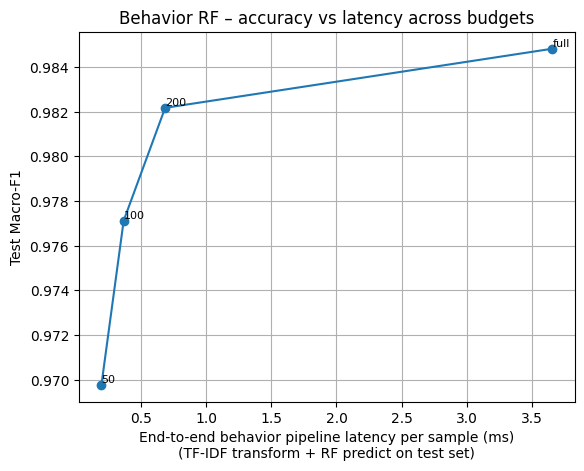

In [22]:
plt.figure()
plt.plot(
    behavior_budget_costs["end_to_end_test_ms"],
    behavior_budget_costs["test_macro_f1"],
    marker="o",
)
for _, row in behavior_budget_costs.iterrows():
    plt.text(
        row["end_to_end_test_ms"],
        row["test_macro_f1"],
        row["budget_label"],
        fontsize=8,
        ha="left",
        va="bottom",
    )

plt.xlabel("End-to-end behavior pipeline latency per sample (ms)\n(TF-IDF transform + RF predict on test set)")
plt.ylabel("Test Macro-F1")
plt.title("Behavior RF – accuracy vs latency across budgets")
plt.grid(True)
plt.show()